## 04 - Train / Validation / Test Split

**Input:** `../data/processed/bank_marketing_clean.csv` and
`../reports/clean_config.json` (Notebook 03).

**The one decision this notebook cannot get wrong:** Notebook 02 (Section
8.1) showed the rows are stored in chronological order, and that the
subscription rate visibly tracks the 2008-2009 interest-rate collapse. A
random shuffle-split would let the model train on contacts made *after*
the test period's economic conditions and be evaluated on contacts made
*before* them leaking future macro-economic information into training,
in a subtler form than the `duration` leakage caught in Notebook 01. The
split here is **chronological**, not random.

This notebook also builds the `ColumnTransformer` that Notebook 03 set up
column roles for, and fits every data-dependent step (imputation values,
one-hot vocabulary) on the training split only.

## 0. Environment & Reproducibility

In [2]:
import sys
import json
import hashlib
import warnings
from pathlib import Path

warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

print(f"Python       : {sys.version.split()[0]}")
print(f"pandas       : {pd.__version__}")
print(f"numpy        : {np.__version__}")
print(f"scikit-learn : {sklearn.__version__}")

pd.set_option("display.max_columns", None)
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")
FIG_DPI = 100
RNG_SEED = 42

Python       : 3.13.13
pandas       : 2.3.3
numpy        : 2.5.2
scikit-learn : 1.9.0


## 1. Load Cleaned Data + Column Roles

`column_roles` from Notebook 03 drives the `ColumnTransformer` below the
groupings (which columns get imputed, which get one-hot encoded) are not
redecided here.

In [3]:
CLEAN_CONFIG_PATH = Path("../reports/clean_config.json")
DATA_PATH = Path("../data/processed/bank_marketing_clean.csv")

for p in (CLEAN_CONFIG_PATH, DATA_PATH):
    if not p.exists():
        raise FileNotFoundError(f"{p} not found. Run Notebook 03 first.")

with open(CLEAN_CONFIG_PATH) as f:
    clean_config = json.load(f)

file_hash = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
if file_hash != clean_config["output_sha256"]:
    raise ValueError("Cleaned data file has changed since Notebook 03 produced it.")

df = pd.read_csv(DATA_PATH)
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")

target_col = clean_config["target_col"]
column_roles = clean_config["column_roles_for_pipeline"]

passthrough_cols = column_roles["numeric_passthrough"] + column_roles["binary_passthrough"]
impute_cols = column_roles["numeric_needs_imputation"]
nominal_cols = column_roles["nominal_needs_encoding"]

print(f"Passthrough columns ({len(passthrough_cols)}): {passthrough_cols}")
print(f"Impute columns ({len(impute_cols)})       : {impute_cols}")
print(f"Nominal (one-hot) columns ({len(nominal_cols)}): {nominal_cols}")

Loaded: 39,404 rows x 24 columns
Passthrough columns (13): ['age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'month_sin', 'month_cos', 'day_of_week_sin', 'day_of_week_cos', 'contacted_before']
Impute columns (2)       : ['pdays_known_days', 'education_ordinal']
Nominal (one-hot) columns (8): ['job', 'marital', 'default', 'housing', 'loan', 'contact', 'poutcome', 'age_group']


## 2. Confirm Chronological Order Survived Cleaning

Notebook 03 dropped duplicate rows and reset the index. Dropping rows
doesn't reorder the rest, but this is cheap to re-verify rather than
assume a silent reordering bug here would invalidate every split
decision that follows.

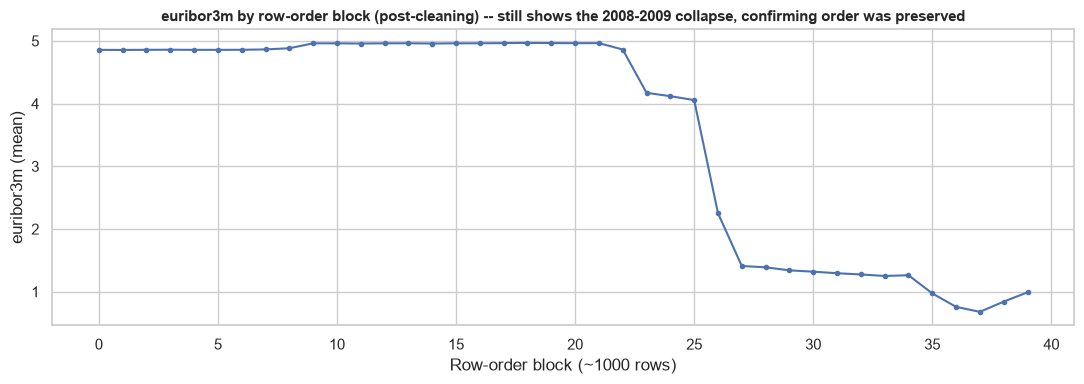

Same step-down pattern as Notebook 02, Section 8.1 -- chronological order intact.


In [4]:
BLOCK_SIZE = 1000
df["_block"] = df.index // BLOCK_SIZE
block_check = df.groupby("_block")["euribor3m"].mean()

fig, ax = plt.subplots(figsize=(11, 4), dpi=FIG_DPI)
ax.plot(block_check.index, block_check.values, marker="o", markersize=3)
ax.set_title("euribor3m by row-order block (post-cleaning) -- still shows the "
             "2008-2009 collapse, confirming order was preserved",
             fontsize=11, fontweight="bold")
ax.set_xlabel(f"Row-order block (~{BLOCK_SIZE} rows)")
ax.set_ylabel("euribor3m (mean)")
plt.tight_layout()
plt.show()

df = df.drop(columns=["_block"])
print("Same step-down pattern as Notebook 02, Section 8.1 -- chronological order intact.")

## 3. Chronological Train / Validation / Test Split

A 70/15/15 split by row order (not shuffled, not stratified by target --
stratifying would require reordering rows, which defeats the point of a
time-aware split). Sizes are large enough (39,404 rows total) that a
15% validation and test split still give several thousand rows each.

In [5]:
n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end].reset_index(drop=True)
val_df = df.iloc[train_end:val_end].reset_index(drop=True)
test_df = df.iloc[val_end:].reset_index(drop=True)

split_sizes = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Rows": [len(train_df), len(val_df), len(test_df)],
    "Row_Range": [f"0:{train_end}", f"{train_end}:{val_end}", f"{val_end}:{n}"],
    "Positive_Rate": [
        (train_df[target_col] == "yes").mean(),
        (val_df[target_col] == "yes").mean(),
        (test_df[target_col] == "yes").mean(),
    ],
})
split_sizes

,Split,Rows,Row_Range,Positive_Rate
0,Train,27582,0:27582,0.058081
1,Validation,5911,27582:33493,0.111995
2,Test,5911,33493:39404,0.394857


### 3.1 The Target-Rate Drift This Split Produced This Needs a Decision, Not Just a Note

The actual numbers here are far more extreme than "some drift": **5.8%
positive in train → 11.2% in validation → 39.5% in test.** The test split
isn't mildly different from train it's a different problem. This is the
direct, mechanical result of the crisis-period rate jump (Notebook 02,
Section 8.1) landing almost entirely inside the last 15% of rows.

This is worth being explicit about rather than smoothing over:

- **A random split would have hidden this** by mixing all three periods
  into every split that would have been leakage, not a fix, so going
  back to random is not the answer.
- **But a test set that is 40% positive does not represent the deployment
  reality** this model will actually face (the overall base rate is
  ~11%). PR-AUC and lift@10%/20% computed on this test split will look
  unrealistically strong and are not directly comparable to how the model
  would perform on a "normal" period going forward.
- **The dataset itself is the constraint**: it spans one economic
  super-cycle (2008 crash → 2010 partial recovery), so *any* strictly
  chronological split concentrates the recovery period at the tail. There
  isn't a clean split of this data that is both leakage-safe and
  distributionally representative.

**Decision carried forward, not resolved here:** validation-split metrics
(11.2% positive, close to the overall rate) are treated as the primary
model-selection signal in `12_cross_validation` / `13_hyperparameter_tuning`
onward. Test-split metrics are still reported in `21_final_test_evaluation`
for completeness, but read as an upper bound under crisis-recovery
conditions, not as an estimate of steady-state performance and this
caveat needs to be repeated wherever test metrics are quoted later in the
project, including in any stakeholder-facing summary.

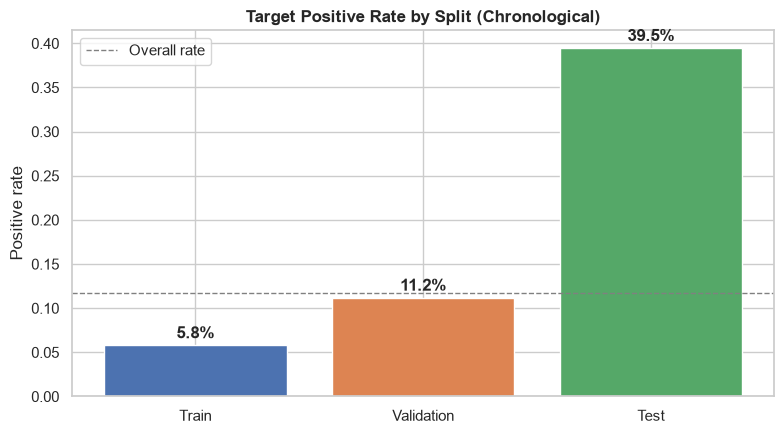

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5), dpi=FIG_DPI)
bars = ax.bar(split_sizes["Split"], split_sizes["Positive_Rate"],
              color=["#4C72B0", "#DD8452", "#55A868"])
ax.axhline(clean_config.get("target_positive_rate", 0.1127) if "target_positive_rate" in clean_config
           else (df[target_col] == "yes").mean(),
           color="gray", linestyle="--", linewidth=1, label="Overall rate")
for bar, rate in zip(bars, split_sizes["Positive_Rate"]):
    ax.annotate(f"{rate:.1%}", xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 5), textcoords="offset points", ha="center", fontweight="bold")
ax.set_title("Target Positive Rate by Split (Chronological)", fontsize=12, fontweight="bold")
ax.set_ylabel("Positive rate")
ax.legend()
plt.tight_layout()
plt.show()

### 3.2 Minimum Viable Class Counts

A quick check that every split has enough positive examples for its
purpose — a validation or test split with too few positives would make
PR-AUC estimates unstable regardless of how correct the split strategy is.

In [7]:
for name, split in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    counts = split[target_col].value_counts()
    print(f"{name:11s}: {counts.get('yes', 0):5,} positive / {counts.get('no', 0):6,} negative "
          f"({counts.get('yes', 0) / len(split):.1%})")
assert all(split[target_col].eq("yes").sum() >= 100
           for split in (train_df, val_df, test_df)), "A split has too few positive examples."
print("\nAll three splits have a usable number of positive examples.")

Train      : 1,602 positive / 25,980 negative (5.8%)
Validation :   662 positive /  5,249 negative (11.2%)
Test       : 2,334 positive /  3,577 negative (39.5%)

All three splits have a usable number of positive examples.


## 4. Preprocessing Pipeline Fit on Train Only

This is where every step Notebook 03 deferred actually happens:
median-imputing `pdays_known_days`/`education_ordinal`, and one-hot
encoding the nominal columns. `OneHotEncoder(handle_unknown="ignore")` is
used deliberately if the validation or test split contains a category
level the training split didn't (possible with `poutcome`/`job`'s rarer
levels), it's encoded as all-zeros rather than crashing or, worse, silently
using information from outside the training split to define it.

In [8]:
X_train, y_train = train_df.drop(columns=[target_col]), (train_df[target_col] == "yes").astype(int)
X_val, y_val = val_df.drop(columns=[target_col]), (val_df[target_col] == "yes").astype(int)
X_test, y_test = test_df.drop(columns=[target_col]), (test_df[target_col] == "yes").astype(int)

preprocessor = ColumnTransformer(
    transformers=[
        ("passthrough", "passthrough", passthrough_cols),
        ("impute_numeric", SimpleImputer(strategy="median"), impute_cols),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False), nominal_cols),
    ],
    remainder="drop",
)

preprocessor.fit(X_train)

impute_values = dict(zip(impute_cols, preprocessor.named_transformers_["impute_numeric"].statistics_))
print("Imputation values learned from TRAIN ONLY:")
for col, val in impute_values.items():
    print(f"  {col:20s}: {val:.2f}")

feature_names = preprocessor.get_feature_names_out()
print(f"\nTotal engineered feature columns after preprocessing: {len(feature_names)}")

Imputation values learned from TRAIN ONLY:
  pdays_known_days    : 5.00
  education_ordinal   : 4.00

Total engineered feature columns after preprocessing: 50


In [9]:
X_train_processed = pd.DataFrame(preprocessor.transform(X_train), columns=feature_names)
X_val_processed = pd.DataFrame(preprocessor.transform(X_val), columns=feature_names)
X_test_processed = pd.DataFrame(preprocessor.transform(X_test), columns=feature_names)

print(f"X_train_processed: {X_train_processed.shape}")
print(f"X_val_processed  : {X_val_processed.shape}")
print(f"X_test_processed : {X_test_processed.shape}")

assert not X_train_processed.isna().any().any(), "NaNs remain in X_train_processed after imputation."
assert not X_val_processed.isna().any().any(), "NaNs remain in X_val_processed after imputation."
assert not X_test_processed.isna().any().any(), "NaNs remain in X_test_processed after imputation."
print("No missing values remain in any split after the pipeline.")

X_train_processed: (27582, 50)
X_val_processed  : (5911, 50)
X_test_processed : (5911, 50)
No missing values remain in any split after the pipeline.


### 4.1 Unseen-Category Check

Confirms the `handle_unknown="ignore"` safety net above actually mattered
(or didn't) for this dataset -- worth knowing either way.

In [10]:
unseen_found = False
for col in nominal_cols:
    train_levels = set(X_train[col].astype(str).unique())
    for name, split_X in [("Validation", X_val), ("Test", X_test)]:
        split_levels = set(split_X[col].astype(str).unique())
        unseen = split_levels - train_levels
        if unseen:
            unseen_found = True
            print(f"{name} has categories in '{col}' not seen in train: {unseen}")
if not unseen_found:
    print("No unseen categories in validation/test -- handle_unknown='ignore' was precautionary, "
          "not load-bearing, for this particular split.")

No unseen categories in validation/test -- handle_unknown='ignore' was precautionary, not load-bearing, for this particular split.


### 4.2 Scaling Deliberately Not Applied Here

No `StandardScaler`/`MinMaxScaler` is fit in this notebook. Tree-based
models (the likely baseline, given the feature mix of one-hot categoricals
and skewed numerics — see Notebook 02, Section 3.3) don't need it, and
applying it unconditionally would be one more data-fit step this notebook
doesn't need to commit to before a model family is chosen. If
`10_baseline_model` / `11_model_training` use a scale-sensitive model
(logistic regression, SVM, neural net), a `StandardScaler` is added to this
same pipeline, fit on `X_train` only, at that point not here.

## 5. Save Splits, Pipeline, and Config

Both the raw (pre-pipeline) splits and the already-processed splits are
saved: the raw versions let a later notebook build a *different*
preprocessing pipeline (e.g. to try target encoding instead of one-hot)
without redoing the split; the processed versions let `10_baseline_model`
start immediately.

In [11]:
OUT_DIR = Path("../data/processed")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Raw (pre-pipeline) splits, target included, for flexibility downstream
train_df.to_csv(OUT_DIR / "train_raw.csv", index=False)
val_df.to_csv(OUT_DIR / "val_raw.csv", index=False)
test_df.to_csv(OUT_DIR / "test_raw.csv", index=False)

# Processed (post-pipeline) feature matrices + targets
X_train_processed.to_csv(OUT_DIR / "X_train_processed.csv", index=False)
X_val_processed.to_csv(OUT_DIR / "X_val_processed.csv", index=False)
X_test_processed.to_csv(OUT_DIR / "X_test_processed.csv", index=False)
y_train.to_csv(OUT_DIR / "y_train.csv", index=False)
y_val.to_csv(OUT_DIR / "y_val.csv", index=False)
y_test.to_csv(OUT_DIR / "y_test.csv", index=False)

# Fitted pipeline, for anything downstream that needs to transform new data identically
joblib.dump(preprocessor, OUT_DIR / "preprocessor.joblib")

split_config = {
    "source_notebook": "04_train_validation_test_split.ipynb",
    "input_sha256": clean_config["output_sha256"],
    "split_strategy": "chronological (row-order), 70/15/15 -- NOT random, per Notebook 02 Section 8.1",
    "split_boundaries": {"train_end_row": train_end, "val_end_row": val_end, "total_rows": n},
    "split_sizes": split_sizes.to_dict(orient="records"),
    "imputation_values_from_train": impute_values,
    "unseen_categories_found": unseen_found,
    "scaling_applied": False,
    "scaling_note": "Deferred to 10_baseline_model/11_model_training if a scale-sensitive model is used; "
                    "must be fit on X_train only if added.",
    "known_risk": (
        "Target positive rate is 5.8% (train) / 11.2% (val) / 39.5% (test) -- a severe, "
        "mechanical consequence of the chronological split landing the 2010 crisis-recovery "
        "period almost entirely in the test set. Test-split metrics should be read as an "
        "upper bound under crisis-recovery conditions, not a steady-state performance "
        "estimate. Validation-split metrics (11.2%, close to the overall 11.3% base rate) "
        "are the primary model-selection signal from 12_cross_validation onward. This caveat "
        "must be repeated wherever test metrics are quoted in 21_final_test_evaluation or later."
    ),
    "output_files": [
        "train_raw.csv", "val_raw.csv", "test_raw.csv",
        "X_train_processed.csv", "X_val_processed.csv", "X_test_processed.csv",
        "y_train.csv", "y_val.csv", "y_test.csv", "preprocessor.joblib",
    ],
}

with open("../reports/split_config.json", "w") as f:
    json.dump(split_config, f, indent=2, default=str)

print("Saved 10 files to ../data/processed/ and ../reports/split_config.json")

Saved 10 files to ../data/processed/ and ../reports/split_config.json


## Conclusion

The split is chronological, not random, because the data is chronologically
ordered and the target rate moves with a real macro-economic cycle
(Notebook 02, Section 8.1) a random split would have hidden that and
leaked future information into training. Every imputation value and the
one-hot vocabulary were fit on the training split only; validation and
test never influenced them.

**The single most important finding in this notebook**, carried forward
as a standing caveat, is the magnitude of the resulting target-rate drift:
5.8% (train) → 11.2% (val) → 39.5% (test). Validation is the primary
signal for model selection and tuning precisely because it sits close to
the dataset's overall base rate; test-split numbers in
`21_final_test_evaluation` need to be reported alongside this caveat, not
as a plain accuracy/PR-AUC figure, or they will overstate what this model
can do in a typical period.

**Next notebook: `09_feature_selection`** using `X_train_processed` /
`y_train` only, decide the macro-economic column reduction deferred in
Notebook 03 (Section 3.4), evaluate whether `age_group` earns its place
next to continuous `age`, and finalise the feature set before
`10_baseline_model`.